# Remaining Useful Life Generation

## Objective

The NASA CMAPSS training dataset does not provide Remaining Useful Life (RUL) labels.

Therefore, the target variable must be generated before any preprocessing or model training.

This notebook demonstrates the functionality of the `RULGenerator` class by generating:

- Raw Remaining Useful Life
- Capped Remaining Useful Life

The notebook also compares both target representations and documents the engineering decisions made during Sprint 4.

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

A:\AI Engineer in the way\ML Projects\Predictive-Maintenance-RUL


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from src.data.loader import DataLoader
from src.data.validator import DataValidator

from src.config.config import (
    TRAIN_DATA_PATH,
    TEST_DATA_PATH,
    RUL_DATA_PATH
)

In [4]:
loader = DataLoader(
    train_path=TRAIN_DATA_PATH,
    test_path=TEST_DATA_PATH,
    rul_path=RUL_DATA_PATH,
)

train_df = loader.load_train()
test_df = loader.load_test()
rul_df = loader.load_rul()

2026-07-22 21:23:12 | INFO | loader.py | Line:18 | Reading train_FD004.txt
2026-07-22 21:23:14 | INFO | loader.py | Line:21 | train_FD004.txt Loaded Successfully
2026-07-22 21:23:14 | INFO | loader.py | Line:18 | Reading test_FD004.txt
2026-07-22 21:23:15 | INFO | loader.py | Line:21 | test_FD004.txt Loaded Successfully
2026-07-22 21:23:15 | INFO | loader.py | Line:18 | Reading RUL_FD004.txt
2026-07-22 21:23:15 | INFO | loader.py | Line:21 | RUL_FD004.txt Loaded Successfully


In [5]:
from src.preprocessing.rul_generator import RULGenerator

In [6]:
generator = RULGenerator(train_df)

raw_df = generator.generate()

2026-07-22 21:24:53 | INFO | rul_generator.py | Line:82 | Generating Remaining Useful Life (RUL)...
2026-07-22 21:24:53 | INFO | rul_generator.py | Line:96 | RUL generated successfully.


In [7]:
raw_df.head()

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670,320
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552,319
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213,318
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176,317
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754,316


In [ ]:
engine = 1

raw_df[raw_df.unit_number == engine][["time_in_cycles","RUL"]].tail()

,time_in_cycles,RUL
316,317,4
317,318,3
318,319,2
319,320,1
320,321,0


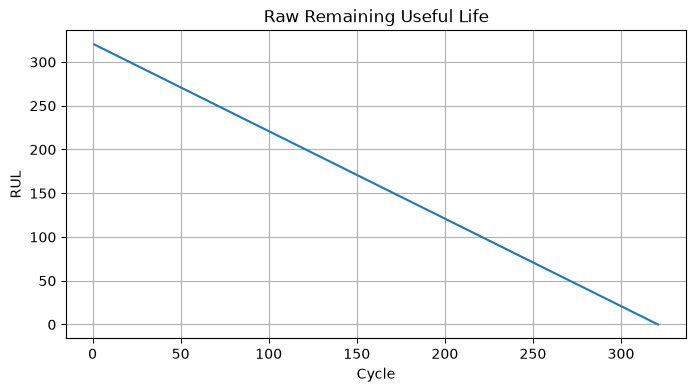

In [ ]:
engine = 1

df = raw_df[raw_df.unit_number == engine]

plt.figure(figsize=(8,4))

plt.plot(
    df.time_in_cycles,
    df.RUL
)

plt.title("Raw Remaining Useful Life")
plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.grid(True)
plt.show()

### Generate Capped RUL

In [10]:
capped_df = generator.generate(cap=125)

2026-07-22 21:27:31 | INFO | rul_generator.py | Line:82 | Generating Remaining Useful Life (RUL)...
2026-07-22 21:27:31 | INFO | rul_generator.py | Line:92 | Applying RUL cap = 125
2026-07-22 21:27:31 | INFO | rul_generator.py | Line:96 | RUL generated successfully.


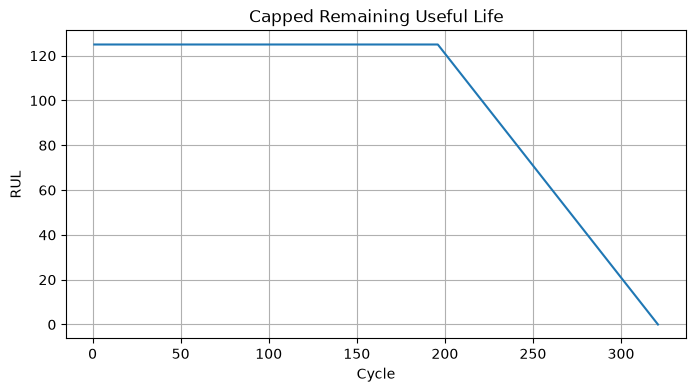

In [12]:
engine = 1

df = capped_df[
    capped_df.unit_number == engine
]

plt.figure(figsize=(8,4))

plt.plot(
    df.time_in_cycles,
    df.RUL
)

plt.grid(True)
plt.title("Capped Remaining Useful Life")
plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.show()

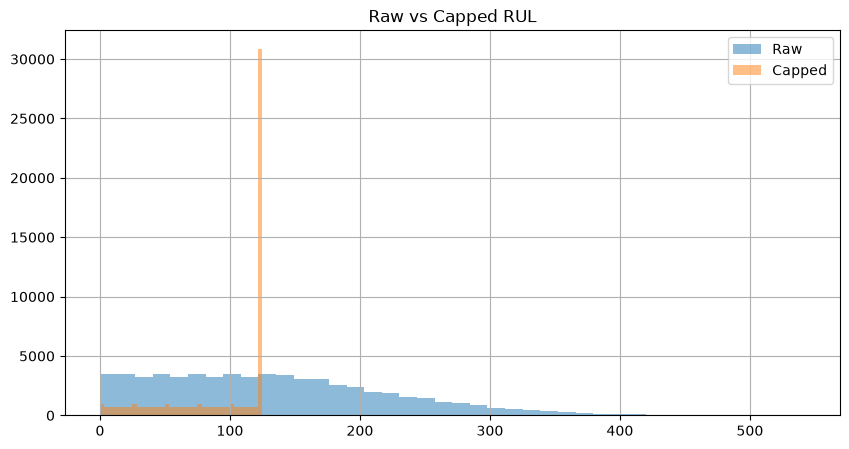

In [13]:
plt.figure(figsize=(10,5))

plt.hist(
    raw_df["RUL"],
    bins=40,
    alpha=.5,
    label="Raw"
)

plt.hist(
    capped_df["RUL"],
    bins=40,
    alpha=.5,
    label="Capped"
)

plt.legend()
plt.title("Raw vs Capped RUL")
plt.grid(True)
plt.show()

In [14]:
comparison = (
    raw_df["RUL"]
    .describe()
    .to_frame("Raw")
)

comparison["Capped"] = (
    capped_df["RUL"]
    .describe()
)

comparison

,Raw,Capped
count,61249.000000,61249.000000
mean,133.311417,92.985192
std,89.783389,40.665112
min,0.000000,0.000000
25%,61.000000,61.000000
50%,122.000000,122.000000
75%,190.000000,125.000000
max,542.000000,125.000000


# Observations

## Raw RUL

- RUL decreases linearly from the engine's maximum cycle to zero.
- Every engine terminates with RUL = 0.
- The generated values correctly reflect the remaining operational cycles.

---

## Capped RUL

- Applying a cap introduces a plateau during the healthy operating period.
- Once the engine enters the degradation region, the target decreases linearly until failure.
- This representation reduces unnecessary variation in high-RUL regions where degradation signals are minimal.

---

## Validation

- The original DataFrame remains unchanged.
- The generated DataFrames contain a new RUL column.
- Both raw and capped targets are generated using the same reusable interface.

# Engineering Decisions

## Decision 1

Target generation is isolated inside the `RULGenerator` class.

---

## Decision 2

The original dataset is never modified.

---

## Decision 3

RUL capping is optional.

---

## Decision 4

A cap of 125 cycles will be adopted during future preprocessing experiments.

---

## Decision 5

Future target representations (normalized or piecewise RUL) can be implemented within the same class without changing the public API.